# Hoja de Trabajo 2: GAN

En esta hoja de trabajo se implementa un DCGAN desde cero utilizando PyTorch para generar
sprites de Pokémon. El dataset fue descargado desde la API pública de PokeAPI en GitHub
utilizando el script download_data.py (generado con IA).

Para asegurar reproducibilidad, se fija una semilla aleatoria al inicio del notebook.
Esto afecta el orden de shuffle del DataLoader, la inicialización de pesos y el ruido
generado durante el entrenamiento.

In [ ]:
import random
import torch

SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

## Task 0: Carga del dataset
Primero, cargamos las imágenes desde la carpeta e implementamos una clase Dataset
para poder utilizar el DataLoader de PyTorch

Para esta sección fue utilizada inteligencia artificial:

*Prompt:* I'm implementing a DCGAN using 64x64 pokemon sprite images, I need to implement
a dataset / dataloader for the training process. They're all in the same data/pokemon
directory. I also want the necessary preprocessing to ensure the images are normalized and of the correct size.

*Por qué funciona:* Fui específico con lo que necesitaba, además ya conocía un poco sobre como trabajar con datasets /
dataloaders por lo cual pude instruirle al LLM sobre la estructura que quería seguir en el Notebook.


In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import glob
import os

# Constantes de imágenes
IMG_SIZE = 64
IMG_CHANNELS = 3


class PokemonDataset(Dataset):
    def __init__(self, root, img_size=IMG_SIZE):
        self.paths = sorted(glob.glob(os.path.join(root, "*.png")))
        self.transform = transforms.Compose(
            [
                transforms.Resize((img_size, img_size)),
                transforms.ToTensor(),
                transforms.Normalize([0.5] * IMG_CHANNELS, [0.5] * IMG_CHANNELS),
            ]
        )

    def __len__(self):
        return len(self.paths)

    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert("RGB")
        return self.transform(img), 0


dataset = PokemonDataset(root="data/pokemon")
print(f"Dataset size: {len(dataset)}")

Dataset size: 898


El tamaño del dataset es correcto, por lo que podemos empezar con la implementación del DCGAN.

# Task 1
En este task se implementa el DCGAN utilizando las reglas / los parámetros de Radford et al. (2015).
## Task 1.1
Primero, empezamos declarando los parámetros fijos.

In [ ]:
Z_DIM = 100
FEATURES_G = 64
FEATURES_D = 64

### Generador
El generador recibe un vector de ruido $z \in \mathbb{R}^{100}$ con forma (batch, 100, 1, 1) y produce
una imagen de forma (batch 3, 64, 64, 64) mediante 5 capas de ConvTranspose2d con los siguientes
canales:

- `FEATURES_G*8` $\rightarrow$ `FEATURES_G*4` $\rightarrow$ BatchNorm + ReLU
- `FEATURES_G*4` $\rightarrow$ `FEATURES_G*2` $\rightarrow$ BatchNorm + ReLU
- `FEATURES_G*2` $\rightarrow$ `FEATURES_G` $\rightarrow$ BatchNorm + ReLU
- `FEATURES_G` $\rightarrow$ `IMG_CHANNELS` $\rightarrow$ BatchNorm + ReLU
- `IMG_CHANNELS` $\rightarrow$ Tanh

Como salida obtenemos una imagen de 64x64

In [ ]:
import torch.nn as nn


class Generator(nn.Module):
    # Init con parámetros globales
    def __init__(self, z_dim=Z_DIM, img_channels=IMG_CHANNELS, features_g=FEATURES_G):
        super().__init__()
        # Input: N x z_dim x 1 x 1
        self.net = nn.Sequential(
            # ConvTranspose2d: z_dim -> features_g * 8
            nn.ConvTranspose2d(
                z_dim, features_g * 8, kernel_size=4, stride=1, padding=0, bias=False
            ),
            # BatchNorm + ReLU
            nn.BatchNorm2d(features_g * 8),
            nn.ReLU(True),
            # ConvTranspose2d: features_g * 8 -> features_g * 4
            nn.ConvTranspose2d(
                features_g * 8,
                features_g * 4,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False,
            ),
            # BatchNorm + ReLU
            nn.BatchNorm2d(features_g * 4),
            nn.ReLU(True),
            # ConvTranspose2d: features_g * 4 -> features_g * 2
            nn.ConvTranspose2d(
                features_g * 4,
                features_g * 2,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False,
            ),
            # BatchNorm + ReLU
            nn.BatchNorm2d(features_g * 2),
            nn.ReLU(True),
            # ConvTranspose2d: features_g * 2 -> features_g
            nn.ConvTranspose2d(
                features_g * 2,
                features_g,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False,
            ),
            # BatchNorm + ReLU
            nn.BatchNorm2d(features_g),
            nn.ReLU(True),
            # ConvTranspose2d: features_g -> img_channels
            nn.ConvTranspose2d(
                features_g, img_channels, kernel_size=4, stride=2, padding=1, bias=False
            ),
            # No BatchNorm + Tanh
            nn.Tanh(),
        )

    # Forward: Pasar vector por la net
    def forward(self, x):
        return self.net(x)

### Discriminador:
El discriminador recibe una imagen (batch, 3, 64, 64) y produce un escalar
por imagen mediante cinco capas Conv2d con stride 2:

- `IMG_CHANNELS` $\rightarrow$ `FEATURES_D` $\rightarrow$ LeakyReLU
- `FEATURES_D` $\rightarrow$ `FEATURES_D*2` $\rightarrow$ BatchNorm + LeakyReLU
- `FEATURES_D*2` $\rightarrow$ `FEATURES_D*4` $\rightarrow$ BatchNorm + LeakyReLU
- `FEATURES_D*4` $\rightarrow$ `FEATURES_D*8` $\rightarrow$ BatchNorm + LeakyReLU
- `FEATURES_D*8` $\rightarrow$ 1 $\rightarrow$ Sigmoid

Como salida obtenemos un escalar entre 0 y 1 que representa la probabilidad
que una imagen sea real o falsa

In [ ]:
class Discriminator(nn.Module):
    # Init con parámetros globales
    def __init__(self, img_channels=IMG_CHANNELS, features_d=FEATURES_D):
        super().__init__()
        # Input: N x img_channels x 64 x 64
        self.net = nn.Sequential(
            # Conv2d: img_channels -> features_d
            nn.Conv2d(
                img_channels, features_d, kernel_size=4, stride=2, padding=1, bias=False
            ),
            # No BatchNorm + LeakyReLU
            nn.LeakyReLU(0.2, inplace=True),
            # Conv2d: features_d -> features_d * 2
            nn.Conv2d(
                features_d,
                features_d * 2,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False,
            ),
            # BatchNorm + LeakyReLU
            nn.BatchNorm2d(features_d * 2),
            nn.LeakyReLU(0.2, inplace=True),
            # Conv2d: features_d * 2 -> features_d * 4
            nn.Conv2d(
                features_d * 2,
                features_d * 4,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False,
            ),
            # BatchNorm + LeakyReLU
            nn.BatchNorm2d(features_d * 4),
            nn.LeakyReLU(0.2, inplace=True),
            # Conv2d: features_d * 4 -> features_d * 8
            nn.Conv2d(
                features_d * 4,
                features_d * 8,
                kernel_size=4,
                stride=2,
                padding=1,
                bias=False,
            ),
            # BatchNorm + LeakyReLU
            nn.BatchNorm2d(features_d * 8),
            nn.LeakyReLU(0.2, inplace=True),
            # Conv2d: features_d * 8 -> 1
            nn.Conv2d(
                features_d * 8, 1, kernel_size=4, stride=1, padding=0, bias=False
            ),
            # No BatchNorm + Sigmoid
            nn.Sigmoid(),
        )

    # Forward: Pasar imagen por la net
    def forward(self, x):
        out = self.net(x)
        return out.view(out.shape[0])

### Verificación:
Aquí simplemente aseguramos que las formas del output sean las esperadas según
las instrucciones de la hoja de trabajo.

In [ ]:
import torch

# Instanciar el generador y el discriminador
G = Generator()
D = Discriminator()

# Verificación de formas
z = torch.randn(4, Z_DIM, 1, 1)
assert G(z).shape == (4, 3, 64, 64), "Forma del generador incorrecta"
assert D(torch.randn(4, 3, 64, 64)).shape == (4,), "Forma del discriminador incorrecta"

## Task 1.2: Entrenamiento alternado
### Generación de Grid de Imágenes
La función make_grid_image recibe el generador, un vector de ruido fijo y una
ruta, y guarda una imagen con un grid de las muestras generadas. Se usa un mismo
ruido fijo entre épocas para poder ver la progresión del generador

Para esta sección fue utilizada inteligencia artificial:

*Prompt:* I'm implementing a DCGAN, I've got the following implementation of the generator:
[código]

I need a function I can call that given a noise vector saves a 4x4 grid of generated images
to a specific path. Make sure generation is totally independent from training

*Por qué funciona:* Nuevamente, fui bastante específico con lo que necesitaba. Además,
se que PyTorch puede ser algo "frágil" cuando se utilizan funciones automáticas de
gradientes, etc. así que me pude ahorrar bugs potenciales instruyéndole a la IA de manera
correcta. También, al brindar la implementación del generador la herramienta ya tiene bastante
claro como funciona por dentro y evita malentendidos / trabajo de más al intentar ser
"overly helpful" e implementar absolutamente todo.

In [ ]:
import matplotlib.pyplot as plt
from torchvision.utils import make_grid


def make_grid_image(gen, noise, path):
    # Generar imágenes sin acumular gradiente
    gen.eval()
    with torch.no_grad():
        fake = gen(noise)  # Generar
        fake = fake * 0.5 + 0.5  # Desnormalizar

    grid = make_grid(fake, nrow=4)
    grid_np = grid.permute(1, 2, 0).cpu().numpy()

    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.figure(figsize=(6, 6))
    plt.imshow(grid_np)
    plt.axis("off")
    plt.savefig(path, bbox_inches="tight")
    plt.close()
    gen.train()

### Función de Entrenamiento
La función train implementa el entrenamiento alternado del DCGAN sobre num_epochs
épocas:

- Se inicializan BCELoss y un optimizador Adam por separado para gen y disc
- Por cada batch, el discriminador da disc_steps pasos de optimización (Utilizado en el Task 2):
  - Generar imágenes falsas a partir de ruido
  - Calcular pérdida sobre reales (label 1) y falsas (label 0), promediarlas
  - Backward + step del optimizador del discriminador
- Luego el generador da un solo paso de optimización:
  - Pasar las imágenes falsas (ya generadas) por el discriminador
  - Calcular pérdida buscando engañar al discriminador (label 1)
  - Backward + step del optimizador del generador
- Al final de cada época se guarda el grid de imágenes generadas con ruido fijo

Como salida obtenemos las listas de pérdidas por época del generador y del discriminador

In [ ]:
# Función de entrenamiento, hiperparámetros del laboratorio por defecto
def train(
    gen,
    disc,
    loader,
    device,
    num_epochs=50,
    lr=2e-4,
    betas=(0.5, 0.999),
    sample_dir="figs/samples/normal",
    disc_steps=1,
):
    # Instanciar BCELoss (aparantemente es una clase y hay que instanciarla)
    criterion = nn.BCELoss()
    # Optimizador del generador
    opt_gen = torch.optim.Adam(gen.parameters(), lr=lr, betas=betas)
    # Optimizador del discriminador
    opt_disc = torch.optim.Adam(disc.parameters(), lr=lr, betas=betas)

    # Colocar en el modo de entrenamiento
    gen.train()
    disc.train()

    # Vector de ruido fijo para generación de imágenes
    fixed_noise = torch.randn(16, Z_DIM, 1, 1, device=device)

    # Pérdidas, una por época
    losses_gen, losses_disc = [], []

    # Loop de entrenamiento
    for epoch in range(num_epochs):
        # Inicializar pérdidas en 0
        epoch_loss_gen, epoch_loss_disc = 0.0, 0.0

        # Para cada batch
        for batch_idx, (real, _) in enumerate(loader):
            # Transferir a GPU
            real = real.to(device)
            batch_size = real.size(0)

            # Entrenamiento de discriminador (disc_steps pasos por cada paso del generador):
            for _ in range(disc_steps):
                # Generar imágenes falsas a partir de ruido
                noise = torch.randn(batch_size, Z_DIM, 1, 1, device=device)
                fake = gen(noise)

                # Paso por las imágenes reales
                disc_real = disc(real)
                loss_disc_real = criterion(disc_real, torch.ones_like(disc_real))

                # Paso por las imágenes falsas, detach para evitar el flujo de gradiente
                disc_fake = disc(fake.detach())
                loss_disc_fake = criterion(disc_fake, torch.zeros_like(disc_fake))

                # Pérdida total del discriminador
                loss_disc = (loss_disc_real + loss_disc_fake) / 2

                # Reiniciar gradientes
                disc.zero_grad()
                # Backward
                loss_disc.backward()
                # Dar paso con optimizador
                opt_disc.step()

            # Entrenamiento de generador (un solo paso):

            # Paso por discriminador
            output = disc(fake)
            loss_gen = criterion(output, torch.ones_like(output))

            # Reiniciar gradientes
            gen.zero_grad()
            # Backward
            loss_gen.backward()
            # Dar paso con optimizador
            opt_gen.step()

            # Acumular pérdidas
            epoch_loss_disc += loss_disc.item()
            epoch_loss_gen += loss_gen.item()

        # Actualizar pérdidas
        epoch_loss_gen /= len(loader)
        epoch_loss_disc /= len(loader)
        losses_gen.append(epoch_loss_gen)
        losses_disc.append(epoch_loss_disc)

        print(
            f"Epoch: [{epoch} / {num_epochs}] Loss D: {epoch_loss_disc:.4f}, Loss G: {epoch_loss_gen:.4f}"
        )

        # Guardar grid de muestras generadas de esta época
        make_grid_image(
            gen, fixed_noise, os.path.join(sample_dir, f"epoch_{epoch + 1:02d}.png")
        )

    return losses_gen, losses_disc

## Task 1.3: Visualizaciones
### Ejecutar Loop de Entrenamiento:
Aquí simplemente instanciamos el generador y el discriminador, cargamos el
dataset en un DataLoader y llamamos a train con los hiperparámetros por defecto
(num_epochs=50, disc_steps=1) para el entrenamiento normal.

In [ ]:
# Inicializar con cuda de ser posible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

# Inicializar generador y discriminador
gen = Generator().to(device)
disc = Discriminator().to(device)

# Cargar dataset
loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Loop de entrenamiento
losses_gen, losses_disc = train(
    gen, disc, loader, device, num_epochs=50, lr=2e-4, sample_dir="figs/samples/normal"
)

Using device: cuda
Epoch: [0 / 50] Loss D: 0.0720, Loss G: 6.8623
Epoch: [1 / 50] Loss D: 0.0282, Loss G: 10.3641
Epoch: [2 / 50] Loss D: 0.6595, Loss G: 9.0403
Epoch: [3 / 50] Loss D: 0.5298, Loss G: 3.4702
Epoch: [4 / 50] Loss D: 0.5070, Loss G: 2.8524
Epoch: [5 / 50] Loss D: 0.3468, Loss G: 3.6485
Epoch: [6 / 50] Loss D: 0.4155, Loss G: 3.3710
Epoch: [7 / 50] Loss D: 0.4824, Loss G: 2.9264
Epoch: [8 / 50] Loss D: 0.4391, Loss G: 3.0868
Epoch: [9 / 50] Loss D: 0.4631, Loss G: 3.2429
Epoch: [10 / 50] Loss D: 0.4416, Loss G: 3.2979
Epoch: [11 / 50] Loss D: 0.4121, Loss G: 3.7663
Epoch: [12 / 50] Loss D: 0.3773, Loss G: 3.9087
Epoch: [13 / 50] Loss D: 0.3480, Loss G: 3.7311
Epoch: [14 / 50] Loss D: 0.3209, Loss G: 4.1400
Epoch: [15 / 50] Loss D: 0.3803, Loss G: 4.3117
Epoch: [16 / 50] Loss D: 0.3726, Loss G: 3.9822
Epoch: [17 / 50] Loss D: 0.3146, Loss G: 4.3262
Epoch: [18 / 50] Loss D: 0.3607, Loss G: 4.1814
Epoch: [19 / 50] Loss D: 0.3233, Loss G: 4.5890
Epoch: [20 / 50] Loss D: 0.358

### Gráfica de Pérdidas
plot_losses grafica las pérdidas del generador y del discriminador por época.

En esta sección se utilizo inteligencia artificial:

*Prompt:* I'm implementing a DCGAN, I've already got the alternating training loop working
and need to graph (& save) a figure of the training loss of each the discriminator and
generator as well as the point where the losses are closest together. Make a function
for this that takes the losses & path as it will be used at varios places in the project.

*Por qué funciona:* El trabajo delegado es realmente simple, simplemente es implementar
una función según los specs descritos.

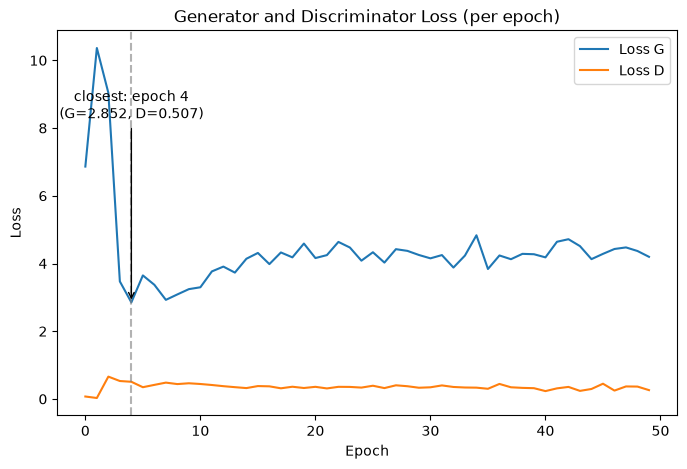

In [ ]:


def plot_losses(losses_gen, losses_disc, path, title):
    epochs = list(range(len(losses_gen)))

    # Point where loss_G and loss_D are closest to each other
    diffs = [abs(g - d) for g, d in zip(losses_gen, losses_disc)]
    closest_epoch = int(min(range(len(diffs)), key=lambda i: diffs[i]))

    os.makedirs(os.path.dirname(path), exist_ok=True)
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, losses_gen, label="Loss G")
    plt.plot(epochs, losses_disc, label="Loss D")
    plt.axvline(closest_epoch, color="gray", linestyle="--", alpha=0.6)
    plt.annotate(
        f"closest: epoch {closest_epoch}\n"
        f"(G={losses_gen[closest_epoch]:.3f}, D={losses_disc[closest_epoch]:.3f})",
        xy=(closest_epoch, losses_gen[closest_epoch]),
        xytext=(closest_epoch, max(losses_gen + losses_disc) * 0.8),
        arrowprops=dict(arrowstyle="->"),
        ha="center",
    )
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.savefig(path, bbox_inches="tight")
    plt.show()


plot_losses(
    losses_gen,
    losses_disc,
    "figs/loss/normal_losses.png",
    "Generator and Discriminator Loss (per epoch)",
)

![epoch_20](figs/samples/normal/epoch_50.png)


# Task 2: Inducir Modo Colapso Artificialmente
## Task 2.1:
Se re-entrena desde cero durante 20 épocas, dejando que el discriminador
dé 5 pasos de optimización por cada paso del generador. Un discriminador
demasiado fuerte satura sus salidas y deja de darle señal útil de
gradiente al generador, empujándolo a colapsar hacia unas pocas salidas
que sí lo engañan (modo colapso).
### Entrenamiento

Epoch: [0 / 20] Loss D: 0.0006, Loss G: 11.2707
Epoch: [1 / 20] Loss D: 0.0008, Loss G: 14.2084
Epoch: [2 / 20] Loss D: 0.0032, Loss G: 10.2309
Epoch: [3 / 20] Loss D: 0.0140, Loss G: 5.5874
Epoch: [4 / 20] Loss D: 0.0128, Loss G: 5.6282
Epoch: [5 / 20] Loss D: 0.0168, Loss G: 5.8052
Epoch: [6 / 20] Loss D: 0.0109, Loss G: 5.5304
Epoch: [7 / 20] Loss D: 0.0075, Loss G: 6.5201
Epoch: [8 / 20] Loss D: 0.0070, Loss G: 6.8227
Epoch: [9 / 20] Loss D: 0.0117, Loss G: 6.3750
Epoch: [10 / 20] Loss D: 0.0044, Loss G: 7.1954
Epoch: [11 / 20] Loss D: 0.0098, Loss G: 6.7851
Epoch: [12 / 20] Loss D: 0.0066, Loss G: 6.7856
Epoch: [13 / 20] Loss D: 0.0047, Loss G: 7.5017
Epoch: [14 / 20] Loss D: 0.0042, Loss G: 8.1467
Epoch: [15 / 20] Loss D: 0.0050, Loss G: 7.5972
Epoch: [16 / 20] Loss D: 0.0056, Loss G: 7.5055
Epoch: [17 / 20] Loss D: 0.0051, Loss G: 8.0281
Epoch: [18 / 20] Loss D: 0.0037, Loss G: 8.0019
Epoch: [19 / 20] Loss D: 0.0046, Loss G: 7.6638


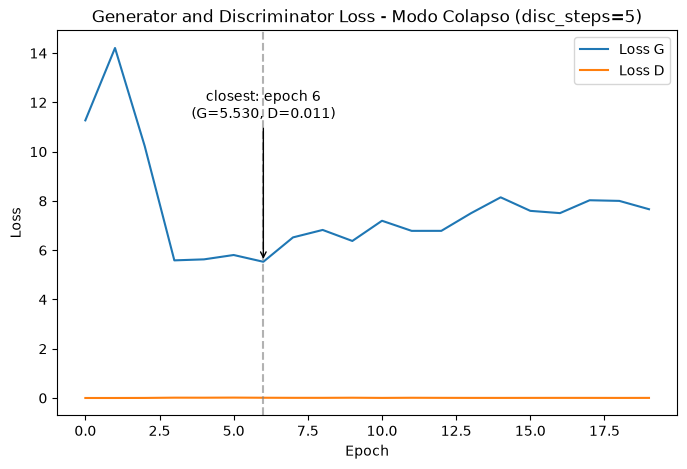

In [ ]:
# Inicializar nuevos gen / disc
gen_collapse = Generator().to(device)
disc_collapse = Discriminator().to(device)

# Entrenar utilizando disc_steps=5 y num_epochs=20, los demás
# hiperparámetros se mantienen
losses_gen_collapse, losses_disc_collapse = train(
    gen_collapse,
    disc_collapse,
    loader,
    device,
    num_epochs=20,
    lr=2e-4,
    sample_dir="figs/samples/collapse",
    disc_steps=5,
)

plot_losses(
    losses_gen_collapse,
    losses_disc_collapse,
    "figs/loss/collapse_losses.png",
    "Generator and Discriminator Loss - Modo Colapso (disc_steps=5)",
)

### Visualización Modo Colapso

![epoch_20](figs/samples/collapse/epoch_20.png)

Podemos ver que claramente tenemos mucha menos variación en comparación al entrenamiento normal, la calidad de las imágenes (como formas, edges más definidos, etc.) es bastante inferior en comparación. En su mayoría, son como "manchas" que suelen parecerse entre si.

### Preguntas:

a) Explique matemáticamente por qué entrenar $D$ muchas más veces que $G$ induce el modo colapso. Su respuesta debe incluir qué le sucede al gradiente
$\nabla_{\theta_g} \mathcal{L}_G$ cuando $D(G(z)) \approx 0$ para todas las muestras, y por qué el generador no puede recuperarse de
ese estado.

**Respuesta:**

Con `disc_steps=5`, $D$ da varios pasos por cada paso de $G$. Entonces se acerca a
su óptimo local más rápido de lo que $G$ puede "reaccionar", por lo tanto separa
reales de falsas de manera casi perfecta. Es decir, $D(G(z)) \approx 0$ para todo z.

Sea $f(x)$ el logit de $D$, con $D(x) = \sigma(f(x))$. Por regla de la cadena,
$\nabla_{\theta_g} \log(1 - D(G(z))) = \dfrac{-\sigma'(f(G(z)))}{1 - D(G(z))} \cdot \nabla_{\theta_g} f(G(z))$.
Cuando $D(G(z)) \approx 0$, el denominador tiende a 1 y $\sigma'(f(G(z))) \approx 0$, así que
todo el producto colapsa. Es decir, $\nabla_{\theta_g} \mathcal{L}_G \approx 0$.

El generador recibe una pérdida alta, pero el gradiente es casi nulo. Entonces, no tiene
una señal que le indique la dirección donde debe moverse sus pesos y estos dejan
de actualizarse. Además, como $D$ sigue teniendo una ventaja al dar 5 pasos, cualquier
variación que pueda ser generada por $G$ se "castiga" de manera inmediata. Por lo tanto,
$G$ converge a las pocas salidas que ocasionalmente si generan gradiente en vez de
explorar la diversidad.

*Nota:* la implementación usa la versión no saturante, en este caso el gradiente respecto
al logit es $-(1- D(G(z))) \rightarrow -1$ por lo que no se anula. Lo que sucede es que la señal
se vuelve poco informativa y de alta varianza cuando $D$ separa perfectamente. En ambos casos
sigue colapsando.

b) En el modo colapso observado, ¿qué valor tiene aproximadamente $D^*(x)$ para las imágenes que el
generador produce repetidamente? Justifique desde la fórmula del discriminador óptimo derivada en clase.

**Respuesta:**

El discriminador óptimo (para $G$ fijo) es $D^*(x) = \dfrac{p_{data}(x)}{p_{data}(x) + p_g(x)}$.
En modo colapso, $G$ produce solo unas pocas imágenes una y otra vez, pero ninguna imagen
real se ve exactamente así, así que $p_{data}(x) \approx 0$ en esos puntos.

Con $p_{data}(x) \approx 0$ arriba y $p_g(x) > 0$ abajo, la fracción da $D^*(x) \approx 0$.

Esto coincide con el inciso a. Aunque $G$ repita las mismas salidas, $D$ las sigue detectando como
falsas casi siempre.

c) Proponga una modificación concreta al loop de entrenamiento (que no sea simplemente cambiar la proporción de pasos)
que podría prevenir el modo colapso en su implementación. Justifique por qué funcionaría en términos del gradiente.

**Respuesta:**

Usar un learning rate más bajo para `opt_disc` que para `opt_gen` (por ejemplo, escalado por
`1/disc_steps`), en vez de `lr=2e-4` para ambos. Así, aunque $D$ dé 5 pasos por cada
paso de $G$, cada paso mueve menos los pesos y $D$ no llega tan rápido a su óptimo.

En términos de gradiente, esto evita que el logit $f(G(z))$ crezca lo suficiente como
para saturar la sigmoide. Si se mantiene acotado, $\sigma'(f(G(z)))$ no colapsa a 0, y
por la regla de la cadena de (a), $\nabla_{\theta_g} \mathcal{L}_G$ sigue siendo
informativo en vez de anularse.

## Task 2.2
Usando su discriminador entrenado en la Parte 1.2, estime empíricamente la divergencia
Jensen-Shannon entre $p_{data}$ y $p_G$ en distintos momentos del entrenamiento.

Recuerde que en clase demostramos:

$$V(D^*, G) = -\log 4 + 2 \cdot \text{JSD}(p_{data} \| p_G)$$

Por lo tanto, dado el valor de $V(D, G)$ en cualquier punto del entrenamiento, se puede estimar:

$$\widehat{\text{JSD}} = \frac{V(D, G) + \log 4}{2}$$

### Cálculo del JSD estimado
`loss_disc` en `train` ya es $-\frac{1}{2}\left(\mathbb{E}[\log D(x)] + \mathbb{E}[\log (1 - D(G(z)))]\right)$,
es decir, $-V(D,G)/2$. Sustituyendo en la fórmula de arriba:

$$\widehat{\text{JSD}} = \log 2 - \text{loss\_D}$$

Usamos `loss_D` porque su fórmula coincide directamente con $V(D,G)$. `loss_G`, en cambio, se
calculó con el truco no-saturante ($-\log D(G(z))$), una expresión distinta que no aparece en
la fórmula del juego minimax y por lo tanto no se utiliza para este cálculo.

Para esta sección fue utilizada inteligencia artificial:

*Prompt:* I've got the epoch losses of the discriminator (loss_disc) from a DCGAN training
loop, already using the standard BCE formulation. I need a small function that estimates the
Jensen-Shannon divergence per epoch from that loss, based on V(D,G) = -log4 + 2*JSD, and a plot
comparing it across two training runs against the theoretical log(2) optimum.

*Por qué funciona:* La tarea es puntual, función de una línea y una gráfica, ambas cosas que ya
había usado antes en el notebook (`plot_losses`). No había ambigüedad en el pedido porque ya le di la fórmula derivada,
así que no había riesgo de que la IA "reinterpretara" el cálculo.

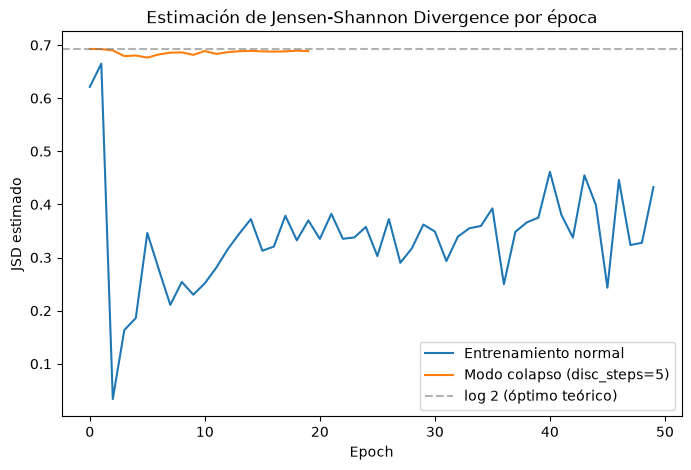

In [ ]:
import math


def compute_jsd(losses_disc):
    return [math.log(2) - ld for ld in losses_disc]


jsd_normal = compute_jsd(losses_disc)
jsd_collapse = compute_jsd(losses_disc_collapse)

plt.figure(figsize=(8, 5))
plt.plot(jsd_normal, label="Entrenamiento normal")
plt.plot(jsd_collapse, label="Modo colapso (disc_steps=5)")
plt.axhline(
    math.log(2), color="gray", linestyle="--", alpha=0.6, label="log 2 (óptimo teórico)"
)
plt.xlabel("Epoch")
plt.ylabel("JSD estimado")
plt.title("Estimación de Jensen-Shannon Divergence por época")
plt.legend()
os.makedirs("figs/jsd", exist_ok=True)
plt.savefig("figs/jsd/jsd_evolution.png", bbox_inches="tight")
plt.show()

### Preguntas:

a) El estimado $\widehat{\text{JSD}}$ que usted calcula asume que $D$ es el discriminador óptimo
$D^*$ para el $G$ actual. En la práctica eso nunca es cierto durante el entrenamiento alternado.
Explique en qué dirección sesga ese supuesto su estimado: ¿lo sobreestima o lo subestima? ¿Por qué?

**Respuesta:**

Lo subestima. $D^*$ es el discriminador que más separa $p_{data}$ de $p_G$, así que da el valor más alto posible de $V(D,G)$ para ese $G$. Nuestro $D$,
entrenado con recursos y pasos limitados nunca alcanza ese óptimo y por lo tanto $V(D,G) \leq V(D^*,G)$.

Como $\widehat{\text{JSD}}$ crece con $V(D,G)$, un $D$ subóptimo da un $V(D,G)$ menor al real,
y por lo tanto un $\widehat{\text{JSD}}$ menor al verdadero JSD entre $p_{data}$ y $p_G$. El
estimado es entonces una cota inferior, no el valor exacto.

b) Hacia el final del entrenamiento, si su GAN ha convergido bien, ¿hacia qué valor debería tender
JSD? Verifique si su curva empírica es consistente con ese valor teórico.

**Respuesta:**

En el equilibrio de Nash, $p_G = p_{data}$ y $D^*(x) = 0.5$ en todas partes, por lo que
$\text{JSD}(p_{data} \| p_G) \to 0$.

Hacia el final del entrenamiento normal (épocas ~40-49), $\widehat{\text{JSD}}$ oscila
aproximadamente entre 0.25 y 0.45, bastante lejos de 0 y sin una tendencia clara a
bajar respecto al resto del entrenamiento. Esto contrasta con el modo colapso, donde
la curva se mantiene cerca de log 2 durante todo el entrenamiento (lo opuesto a la
convergencia), pero no es realmente consistente con el valor teórico de 0 esperado
en el equilibrio de Nash.

La curva del entrenamiento normal tampoco es monótona, cae fuerte en las primeras
épocas (de ~0.62 a un mínimo de ~0.06 alrededor de la época 3-4) y luego vuelve a
subir y oscila sin estabilizarse.
Esto es consistente con el sesgo hacia abajo explicado en el inciso a, como $D$ nunca
es óptimo durante el entrenamiento alternado la estimación subestima el JSD real,
por lo que el valor verdadero podría ser incluso mayor al que se observa acá. En
resumen, la curva empírica no es consistente con una convergencia al valor teórico
de 0. Se mantiene en una meseta de ruido alejada de 0 durante buena parte del
entrenamiento, por lo que no podemos asegurar que el GAN haya convergido bien.

## Task 3
### Paper Elegido

M. Heusel, H. Ramsauer, T. Unterthiner, B. Nessler, and S. Hochreiter, "GANs trained by a two time-scale update rule converge to a local Nash equilibrium," in
Advances in Neural Information Processing Systems 30 (NeurIPS), Long Beach, CA, USA, 2017, pp. 6626–6637.

Link: https://papers.nips.cc/paper_files/paper/2017/file/8a1d694707eb0fefe65871369074926d-Paper.pdf

### Investigación

El paper trata sobre la problemática de la convergencia de los GANs. La solución es un equilibrio de Nash, pero el descenso de gradiente es un método local y por lo
tanto puede tender a oscilar o divergir en vez de converger. Este fenómeno se puede observar claramente dentro de la GAN implementada en el laboratorio, a partir
de las primeras épocas (5-10) empezamos a ver una oscilación constante sin una mejora observable. Formalmente, el paper dice lo siguiente:

Sean $g = \nabla_{w} \mathcal{L}_D$ y $h = \nabla_{\theta} \mathcal{L}_G$ los gradientes reales, al utilizar mini-batches en el mundo real obtenemos los gradientes
$\tilde{g}(\theta, w) = g(\theta, w) + M^{(w)}$ y $\tilde{h}(\theta, w) = h(\theta, w) + M^{(\theta)}$ como aproximaciones estocásticas, donde $M^{(w)}$ y
$M^{(\theta)}$ son variables aleatorias de error.

Este ruido es la causa formal del problema. Bajo una única escala de tiempo (learning rate), lo único que puede demostrarse es que a través de las iteraciones
"pasamos" por el vecindario de una solución. Este depende de las cotas de error y puede llegar a ser muy grande, esto se ejemplifica dentro del paper citando
Zhang et al. donde las cotas son grandes y directamente se diverge. Cabe notar que el ruido por sí solo no rompe nada, ya que con un objetivo fijo los errores se
promedian y se cancelan. Este problema es específico a los GANs, ya que el objetivo del discriminador cambia constantemente
y el generador también recibe gradiente en base a este. Entonces, estamos entrenando dos redes que han "convergido a medias".


La solución que se propone es mantener dos learning rates diferentes en lugar de uno. Si el learning rate del discriminador es más grande, entonces este deja
de "perseguir" un objetivo en movimiento. Entonces, esta red logra aproximar un discriminador apropiado. Por otro lado, con un learning rate pequeño el generador
se mueve tan lento que apenas perturba al discriminador, y a cambio recibe gradientes provenientes de una red bien entrenada. Formalmente, se usan $b(n)$ para el
discriminador y $a(n)$ para el generador bajo la condición $a(n) = o(b(n))$, es decir, el paso del generador debe ser despreciable frente al del discriminador.
Bajo esta condición el Teorema 1 (Borkar, 1997) garantiza la convergencia a un equilibrio de Nash local estacionario. Cabe notar que el paper no modifica la
función de valor $V(D,G)$, la propuesta aplica igual para la pérdida original o para WGAN.

*Nota: La matemática del paper va mucho más allá de lo que se, así que simplifiqué bastante.*

Para aplicar la solución dentro de este Notebook, sería realmente simple. Basta con instanciar dos optimizadores Adam con learning rates distintos en lugar de
compartir el mismo valor, por ejemplo $b = 4\times10^{-4}$ para el discriminador y $a = 1\times10^{-4}$ para el generador. El ciclo de entrenamiento permanece
igual, un paso de cada red por batch. También vale la pena volver a mencionar que esta es una solución a una problemática observada dentro de esta hoja
de trabajo. Viendo las gráficas de pérdida, luego de las primeras épocas se empiezan a ver oscilaciones que ejemplifican exactamente los "pasos por la vecindad"
del equilibro de Nash que se referencian dentro del paper.

### Aplicación de TTUR
Aplicamos la solución propuesta por el paper: dos learning rates distintos, uno más
grande para el discriminador ($b=4\times10^{-4}$) y uno más pequeño para el generador
($a=1\times10^{-4}$), en vez de compartir `lr=2e-4` como antes. Como `train` solo acepta
un único `lr` compartido entre ambos optimizadores, se define `train_ttur`, una copia
mínima de `train` que únicamente cambia la inicialización de los optimizadores para
usar dos learning rates.

Epoch: [0 / 200] Loss D: 0.0329, Loss G: 8.6507
Epoch: [1 / 200] Loss D: 0.2255, Loss G: 12.1985
Epoch: [2 / 200] Loss D: 0.1148, Loss G: 10.5298
Epoch: [3 / 200] Loss D: 0.1876, Loss G: 9.7049
Epoch: [4 / 200] Loss D: 0.1114, Loss G: 9.0894
Epoch: [5 / 200] Loss D: 0.4490, Loss G: 5.6952
Epoch: [6 / 200] Loss D: 0.3189, Loss G: 5.0705
Epoch: [7 / 200] Loss D: 0.3972, Loss G: 4.3141
Epoch: [8 / 200] Loss D: 0.3252, Loss G: 4.1684
Epoch: [9 / 200] Loss D: 0.1579, Loss G: 5.0853
Epoch: [10 / 200] Loss D: 0.3794, Loss G: 5.2657
Epoch: [11 / 200] Loss D: 0.3335, Loss G: 4.3411
Epoch: [12 / 200] Loss D: 0.4458, Loss G: 4.1503
Epoch: [13 / 200] Loss D: 0.2399, Loss G: 4.1249
Epoch: [14 / 200] Loss D: 0.2206, Loss G: 4.5006
Epoch: [15 / 200] Loss D: 0.4804, Loss G: 3.2759
Epoch: [16 / 200] Loss D: 0.2943, Loss G: 4.4624
Epoch: [17 / 200] Loss D: 0.2949, Loss G: 4.5250
Epoch: [18 / 200] Loss D: 0.2620, Loss G: 4.5405
Epoch: [19 / 200] Loss D: 0.2700, Loss G: 5.2846
Epoch: [20 / 200] Loss D: 0.

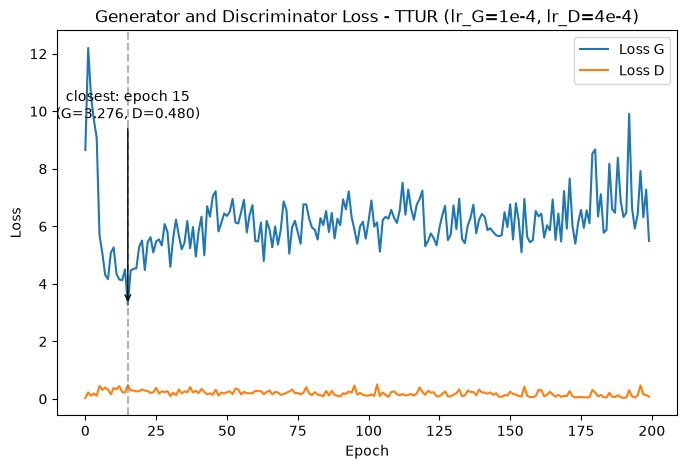

In [ ]:
def train_ttur(
    gen,
    disc,
    loader,
    device,
    num_epochs=50,
    lr_gen=1e-4,
    lr_disc=4e-4,
    betas=(0.5, 0.999),
    sample_dir="figs/samples/ttur",
    disc_steps=1,
):
    criterion = nn.BCELoss()
    # Learning rate distinto por optimizador (TTUR)
    opt_gen = torch.optim.Adam(gen.parameters(), lr=lr_gen, betas=betas)
    opt_disc = torch.optim.Adam(disc.parameters(), lr=lr_disc, betas=betas)

    gen.train()
    disc.train()

    fixed_noise = torch.randn(16, Z_DIM, 1, 1, device=device)
    losses_gen, losses_disc = [], []

    for epoch in range(num_epochs):
        epoch_loss_gen, epoch_loss_disc = 0.0, 0.0

        for batch_idx, (real, _) in enumerate(loader):
            real = real.to(device)
            batch_size = real.size(0)

            for _ in range(disc_steps):
                noise = torch.randn(batch_size, Z_DIM, 1, 1, device=device)
                fake = gen(noise)

                disc_real = disc(real)
                loss_disc_real = criterion(disc_real, torch.ones_like(disc_real))

                disc_fake = disc(fake.detach())
                loss_disc_fake = criterion(disc_fake, torch.zeros_like(disc_fake))

                loss_disc = (loss_disc_real + loss_disc_fake) / 2

                disc.zero_grad()
                loss_disc.backward()
                opt_disc.step()

            output = disc(fake)
            loss_gen = criterion(output, torch.ones_like(output))

            gen.zero_grad()
            loss_gen.backward()
            opt_gen.step()

            epoch_loss_disc += loss_disc.item()
            epoch_loss_gen += loss_gen.item()

        epoch_loss_gen /= len(loader)
        epoch_loss_disc /= len(loader)
        losses_gen.append(epoch_loss_gen)
        losses_disc.append(epoch_loss_disc)

        print(
            f"Epoch: [{epoch} / {num_epochs}] Loss D: {epoch_loss_disc:.4f}, Loss G: {epoch_loss_gen:.4f}"
        )

        make_grid_image(
            gen, fixed_noise, os.path.join(sample_dir, f"epoch_{epoch + 1:02d}.png")
        )

    return losses_gen, losses_disc


# Inicializar nuevos gen / disc
gen_ttur = Generator().to(device)
disc_ttur = Discriminator().to(device)

# Entrenar con TTUR: lr_disc > lr_gen (b=4e-4, a=1e-4), como propone el paper
losses_gen_ttur, losses_disc_ttur = train_ttur(
    gen_ttur,
    disc_ttur,
    loader,
    device,
    num_epochs=200,
    lr_gen=1e-4,
    lr_disc=4e-4,
    sample_dir="figs/samples/ttur",
)

plot_losses(
    losses_gen_ttur,
    losses_disc_ttur,
    "figs/loss/ttur_losses.png",
    "Generator and Discriminator Loss - TTUR (lr_G=1e-4, lr_D=4e-4)",
)

### Visualización TTUR (200 épocas)

![epoch_200](figs/samples/ttur/epoch_200.png)

![ttur_losses](figs/loss/ttur_losses.png)

### Análisis

*Nota: Con CUDA el entrenamiento no es determinista, el comentario va más orientado
a las generalidades que logré observar luego de correrlo varias veces. En algunas runs
las imágenes si parecen un poco más coherentes que en otras. También es interesante
ver como van cambiando conforme las épocas, por si quieren meterse a ver*

Comparado con las muestras de la época 50 del entrenamiento normal, las imágenes de la
época 200 con TTUR sí muestran algo más de detalle y variación de forma entre las 16
muestras (algunas siluetas más definidas, colores menos uniformes), pero siguen siendo
manchas de color sin una estructura de "sprite" reconocible. Es decir, entrenar más
tiempo ayuda un poco a la textura pero no resuelve el problema de fondo.

La curva de pérdida cuenta la misma historia, después de la caída inicial (épocas 0-10)
ambas pérdidas se estabilizan en una oscilación de ruido que se mantiene prácticamente
igual entre la época 20 y la 200 (Loss G oscilando entre ~4 y ~7, Loss D entre ~0.2 y ~0.6).
No hay una tendencia de mejora sostenida en las últimas 150 épocas, solo ruido alrededor
del mismo nivel. Esto sugiere que entrenar por más épocas con este dataset y arquitectura
no está agregando información nueva, el modelo llegó a un saddle point bastante antes de la
época 200.

Una causa probable es el tamaño del dataset (con ~900 imágenes), el discriminador puede
memorizar y separar reales de falsas con relativamente poco esfuerzo, y el generador no
tiene suficiente diversidad de ejemplos reales para aprender variaciones finas. Esto es
consistente con el TTUR usado aquí (lr_D=4e-4 > lr_G=1e-4): Loss D se mantiene baja y
estable (~0.3), es decir el discriminador domina rápidamente, y el generador recibe una
señal de gradiente razonable pero limitada por la poca variedad de datos reales, no por
falta de tiempo de entrenamiento. En resumen, el resultado es "aceptable" para un DCGAN
simple entrenado desde cero, pero la cantidad de datos parece ser el techo.